# 1D convolution problem 

Recover 1D function from blurred, noisy data along with prior precision hyperparameter

Gaussian prior, gamma hyperpriors

Uses Gibbs sampler to replicate the results of "MCMC-Based Image Reconstruction with Uncertainty Quantification", Bardsley, 2012

In [1]:
import numpy as np
import scipy.stats as stats
import matplotlib.pyplot as plt
from scipy.linalg import solve_triangular

In [2]:
# Define the true signal (1D image)
def true_signal(x):
    return 50*np.exp(-((x-0.75)/0.1)**2) + 37*np.logical_and(x>0.1,x<0.25) + 13*np.logical_and(x>0.3,x<0.32) 

# Generate observed blurred data
def generate_blurred_data(true_signal, x, A, lam):
    noise_std = 1/np.sqrt(lam)
    blurred_signal = np.dot(A,true_signal(x))
    noise = np.random.normal(0, noise_std, len(x))
    return blurred_signal + noise

# Define a Gaussian blur kernel
def gaussian_kernel(x, gamma):
    return np.exp(-x**2 / (2 * gamma**2))/np.sqrt(np.pi*gamma**2)

# Gibbs sampler
def gibbs(delta_initial, lam_initial, observed_data, A, L, N, alpha_del, beta_del, alpha_lam, beta_lam, n_iter=10):
    theta_samples = np.zeros((N,n_iter))
    lam_samples = np.zeros(n_iter+1)
    delta_samples = np.zeros(n_iter+1)
    lam_samples[0] = lam_initial
    delta_samples[0] = delta_initial
    
    for idx in range(n_iter):
        K = np.linalg.cholesky(lam_samples[idx]*np.dot(np.transpose(A),A) + delta_samples[idx]*L)
        w = np.dot(K,np.random.randn(N))
        y = solve_triangular(K,lam_samples[idx]*np.dot(np.transpose(A),observed_data) + w, lower=True)
        theta_samples[:,idx] = solve_triangular(K,y,lower=True,trans='T')
        
        lam_shape = N/2 + alpha_lam
        delta_shape = N/2 + alpha_del
        lam_rate = np.sum(0.5 * (observed_data - np.dot(A,theta_samples[:,idx]))**2) + beta_lam
        delta_rate = 0.5 * np.dot(theta_samples[:,idx],np.dot(L,theta_samples[:,idx])) + beta_del
        
        lam_samples[idx+1] = np.random.gamma(lam_shape, 1/lam_rate)
        delta_samples[idx+1] = np.random.gamma(delta_shape, 1/delta_rate)
        
    return theta_samples, delta_samples, lam_samples

In [3]:
# Parameters and generating noisy blurred data

np.random.seed(42)
# discretization dimension
N = 80
x = np.linspace(0, 1, N)
# width of convolution stencil -- in this case the full interval
kernel_size = N
# stdev of gaussian convolution kernel
kernel_gamma = 0.03
# noise precision
lam = 5.35
# hyperprior parameters
alpha_del = 1
beta_del = 1e-4
alpha_lam = 1
beta_lam = 1e-4
# number of Gibbs iterations
iters = 1000

# blurring matrix
A = np.zeros((N,N))
for i in range(N):
    for j in range(N):
        d = min(np.abs(i-j),N-np.abs(i-j))
        A[i,j] = gaussian_kernel(d/N, kernel_gamma)/N
# fix scaling (since h=1/N isn't small enough for the kernel to integrate to ~1 numerically)
A = A/np.sum(A[0,:]) 

# Generate data
observed_data = generate_blurred_data(true_signal, x, A, lam)

# # Initial guess for the hyperparameters
lam_initial = 3
delta_initial = 0.4

# Gibbs Sampling

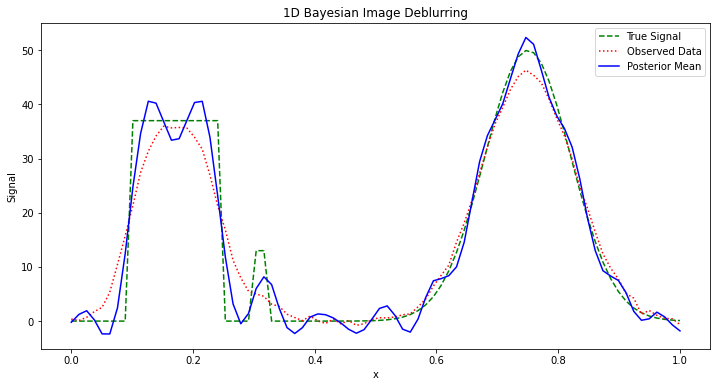

In [4]:
# Run Gibbs sampling

# Prior precision matrix
# Laplacian
L_gibbs = 2*np.diag(np.ones(N)) - np.diag(np.ones(N-1), k=1) - np.diag(np.ones(N-1), k=-1)

# theta_samples, delta_samples = gibbs(delta_initial, observed_data, A, L_gibbs, N, lam, alpha_del, beta_del, n_iter=iters)
theta_samples, delta_samples, lam_samples = gibbs(delta_initial, lam_initial, observed_data, A, L_gibbs, N, alpha_del, beta_del, alpha_lam, beta_lam, n_iter=iters)

# Burn-in
start_idx = int(np.floor(iters/5))

# Compute the posterior mean
posterior_mean = np.mean(theta_samples[:,start_idx:iters-1], axis=1)

# Plot results
plt.figure(figsize=(12, 6))
plt.plot(x, true_signal(x), label="True Signal", linestyle='dashed', color='green')
plt.plot(x, observed_data, label="Observed Data", linestyle='dotted', color='red')
plt.plot(x, posterior_mean, label="Posterior Mean", color='blue')
plt.legend()
plt.title("1D Bayesian Image Deblurring")
plt.xlabel("x")
plt.ylabel("Signal")
plt.show()

Text(0.5, 1.0, 'Prior precision distribution')

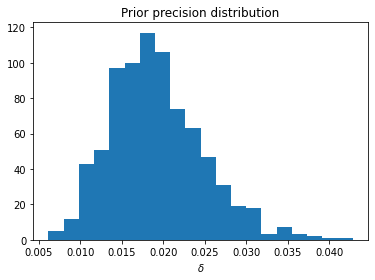

In [11]:
plt.hist(delta_samples[start_idx:iters],bins=20)
plt.xlabel(r'$\delta$')
plt.title('Prior precision distribution')

Text(0.5, 1.0, 'Noise precision distribution')

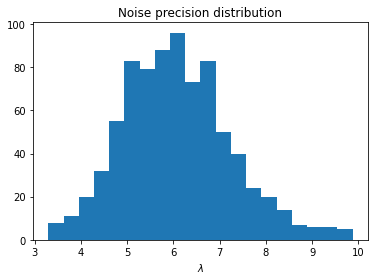

In [12]:
plt.hist(lam_samples[start_idx:iters],bins=20)
plt.xlabel(r'$\lambda$')
plt.title('Noise precision distribution')